In [2]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study3.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.respon

In [3]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_accommodate['free_texts'] = df_accommodate['free_texts'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)



In [18]:
texts = df_accommodate.loc[df_accommodate['participant'] == 5, 'free_texts']

flat_texts = [item for sublist in texts for item in sublist]

print("\n".join(flat_texts))

Because it's vibrant color makes it more noticeable to predators which is an undesirable trait 
Red can be a warning indicator so predators are not interested making this a desirable trait 
The color of this critter can serve as a warning which is a desirable trait 
The fingers of this little guy are pointy which aids in protection and is a desirable trait 
I am getting very confused and having a hard time finding correlations, maybe rounded fingers are bad? 
The colors and fingers don't seem to matter I am not sure 
Okay maybe pointy fingers and spots are a postitve thing 
Again pointy fingers and sport regardless of color seem to have high fertility scores 
This rules out spots I am only seeing a difference in round and pointy fingers 
It has pointy fingers this could be used for foraging or protection 
Now this one has a somewhat high score and rounded fingers so I am confused again
Pointy fingers and is still high, is this a social experiment? 
If the next one is five maybe that is

In [78]:
functional_explanations = [1, 5, 7, 13, 14, 18, 20, 22, 25, 29, 33, 37, 43, 45, 49, 50, 54, 56, 60, 65, 71, 72, 
                           75, 79, 83, 84, 86, 87, 89, 90, 92, 93, 97, 98, 100, 101, 105, 106, 112, 113, 121,
                           129, 131, 132, 133, 134, 136, 138, 140, 141, 142, 144, 147, 156, 159, 166, 173, 180,
                           187, 191, 194, 196, 200, 204, 206, 216, 219]
functional_explanations_feet = [1, 5, 7, 13, 29, 33, 37, 45, 54, 56, 72, 75, 79, 83, 89, 93, 97, 98, 106, 113,
                                121, 132, 134, 136, 142, 159, 166, 180, 187, 191, 194, 196, 204, 219]
functional_explanations_color = [1, 5, 7, 13, 14, 18, 20, 22, 25, 29, 33, 37, 43, 45, 49, 50, 54, 56, 60, 65, 71,
                                 75, 79, 84 ,86, 87, 90, 92, 93, 97, 98, 100, 101, 105, 106, 112, 121, 131, 133,
                                 136, 138, 140, 141, 142, 144, 147, 156, 159, 166, 173, 187, 194, 196, 200, 204,
                                 206, 216, 219]
functional_explanations_others = [11, 14, 15, 17, 23, 24, 27, 29, 37, 49, 50, 68, 70, 81, 82, 83, 84, 86, 87, 95,
                                  102, 105, 131, 134, 142, 144, 169, 162, 180]

In [73]:
print(len(functional_explanations_feet))
print(len(functional_explanations_color))
print(len(functional_explanations))

34
58
67


In [74]:
print(len(df_accommodate))

217


In [75]:
functional_explanations = [
    1, 5, 7, 13, 14, 18, 20, 22, 25, 29, 33, 37, 43, 45, 49, 50, 54, 56, 60, 65,
    71, 72, 75, 79, 83, 84, 86, 87, 89, 90, 92, 93, 97, 98, 100, 101, 105, 106,
    112, 113, 121, 129, 131, 132, 133, 134, 136, 138, 140, 141, 142, 144, 147,
    156, 159, 166, 173, 180, 187, 191, 194, 196, 200, 204, 206, 216, 219
]

df_accommodate.loc[
    df_accommodate['participant'].isin(functional_explanations),
    'task'
] = 'accommodate_functional'

In [79]:
functional_explanations_feet = [1, 5, 7, 13, 29, 33, 37, 45, 54, 56, 72, 75, 79, 83, 89, 93, 97, 98, 106, 113,
                                121, 132, 134, 136, 142, 159, 166, 180, 187, 191, 194, 196, 204, 219]
functional_explanations_color = [1, 5, 7, 13, 14, 18, 20, 22, 25, 29, 33, 37, 43, 45, 49, 50, 54, 56, 60, 65, 71,
                                 75, 79, 84 ,86, 87, 90, 92, 93, 97, 98, 100, 101, 105, 106, 112, 121, 131, 133,
                                 136, 138, 140, 141, 142, 144, 147, 156, 159, 166, 173, 187, 194, 196, 200, 204,
                                 206, 216, 219]

feet_set = set(functional_explanations_feet)
color_set = set(functional_explanations_color)

# Boolean indicators
df_accommodate['functional_feet'] = df_accommodate['participant'].isin(feet_set)
df_accommodate['functional_color'] = df_accommodate['participant'].isin(color_set)

df_accommodate['functional_type'] = np.select(
    [
        df_accommodate['functional_feet'] & df_accommodate['functional_color'],
        df_accommodate['functional_feet'],
        df_accommodate['functional_color']
    ],
    [
        'both',
        'feet_only',
        'color_only'
    ],
    default='none'
)

In [80]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
print(df_combined)

     participant                                         free_texts  \
0            183  [Because it’s orange , Because it’s orange , N...   
1             75  [seems to blend well with local flora, disguis...   
2            100  [It mates in the forest., It is hard to see in...   
3             61  [Looks young as it has a tail, Finally I can t...   
4             97  [The reptile appears to lack sufficient maturi...   
..           ...                                                ...   
429           52                                                NaN   
430          147                                                NaN   
431            9                                                NaN   
432          204                                                NaN   
433          120                                                NaN   

                                              feedback  \
0                                                   []   
1                              

overfit      False  True 
task                     
accommodate    122     95
predict        150     67
Chi-square = 7.180
df = 1
p-value = 0.0074


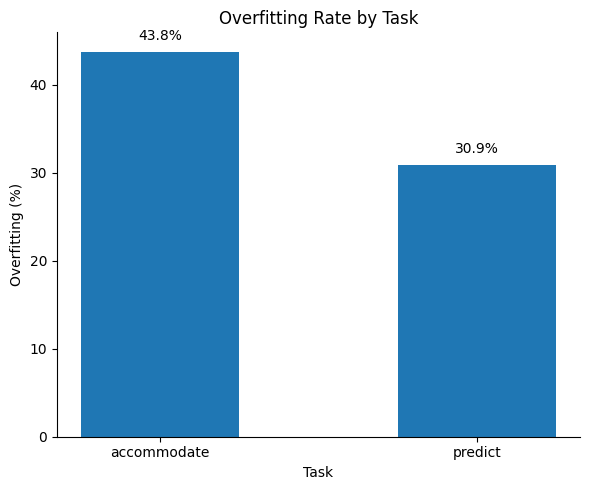

In [97]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate,
        'model_param_score': model_param_score,
        'functional_type': row['functional_type'],
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'relevant_dim': row['relevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit_summary = (
    df_params
    .groupby('task')['overfit']
    .mean()
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['overfit'] * 100

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    overfit_summary['task'],
    overfit_summary['overfit_percent'],
    width=0.5
)

# Labels
ax.set_ylabel('Overfitting (%)')
ax.set_xlabel('Task')
ax.set_title('Overfitting Rate by Task')

# Clean look (matches your usual style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

overfit          False  True 
functional_type              
both                 6     20
color_only          28      4
feet_only            3      5
none                85     66


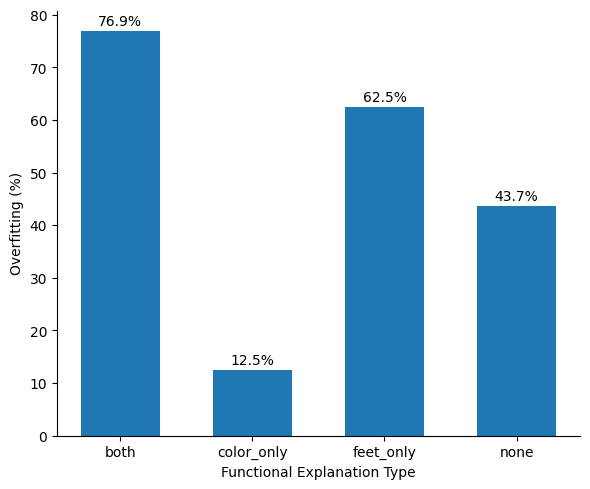

In [98]:
participant_level = df_params.drop_duplicates(subset=['participant', 'task'])
print(
    pd.crosstab(
        participant_level['functional_type'],
        participant_level['overfit']
    )
)

import matplotlib.pyplot as plt

# Compute % overfitting
plot_data = (
    participant_level
    .groupby('functional_type')['overfit']
    .mean()
    .reset_index()
)

plot_data['overfit_percent'] = plot_data['overfit'] * 100

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    plot_data['functional_type'],
    plot_data['overfit_percent'],
    width=0.6
)

# Labels
ax.set_ylabel('Overfitting (%)')
ax.set_xlabel('Functional Explanation Type')

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add values
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

          task functional_type irrelevant_dim      mean  sum  count  \
0  accommodate            both          color  0.687500   11     16   
1  accommodate            both           feet  0.900000    9     10   
2  accommodate      color_only          color  0.076923    1     13   
3  accommodate      color_only           feet  0.157895    3     19   
4  accommodate       feet_only          color  0.750000    3      4   
5  accommodate       feet_only           feet  0.500000    2      4   
6  accommodate            none          color  0.391892   29     74   
7  accommodate            none           feet  0.480519   37     77   

   overfit_percent  
0        68.750000  
1        90.000000  
2         7.692308  
3        15.789474  
4        75.000000  
5        50.000000  
6        39.189189  
7        48.051948  


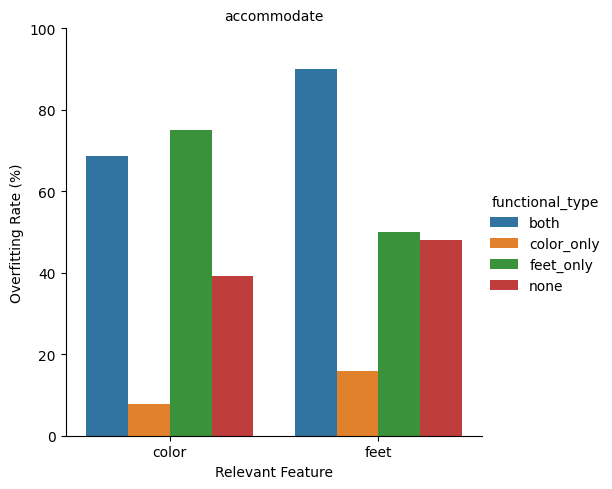

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summarize from participant-level data
overfit_summary = (
    participant_level
    .groupby(['task', 'functional_type', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

# Plot
g = sns.catplot(
    data=overfit_summary,
    x='irrelevant_dim',
    y='overfit_percent',
    hue='functional_type',
    col='task',
    kind='bar',
    height=5,
    aspect=1
)

g.set_axis_labels('Relevant Feature', 'Overfitting Rate (%)')
g.set_titles('{col_name}')
g.set(ylim=(0, 100))

for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

In [103]:
#Create map from short codes to feature descriptions

feet_map = {
    'round': 'f',
    'curly/pointy': 'c'
}

color_map = {
    'red': 'y',
    'green': 'g'
}



feature_maps = {
    'feet': feet_map,
    'color': color_map
}

#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'color']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
if debug:
    print(df_combined['feet_importance'])

import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance', 'functional_type',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_combined[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['functional_type', 'participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)


response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curl

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/2082726775.py:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


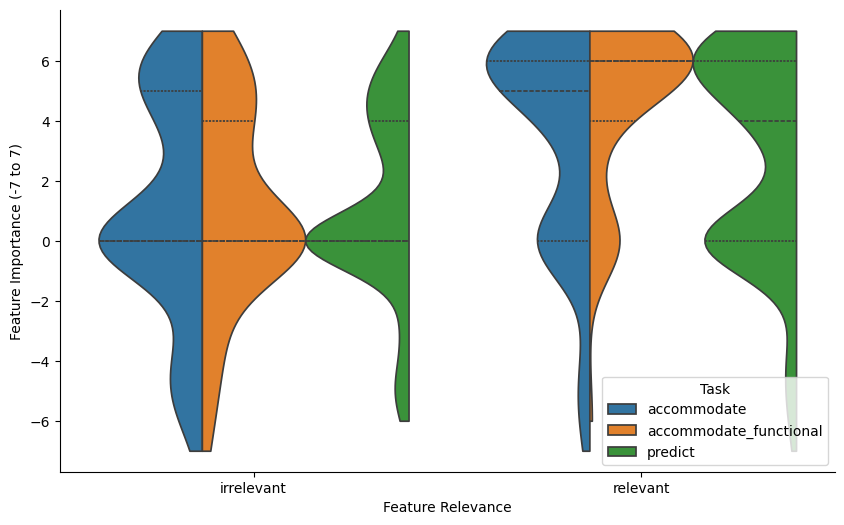

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0,
    scale = 'width'
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/3362599580.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


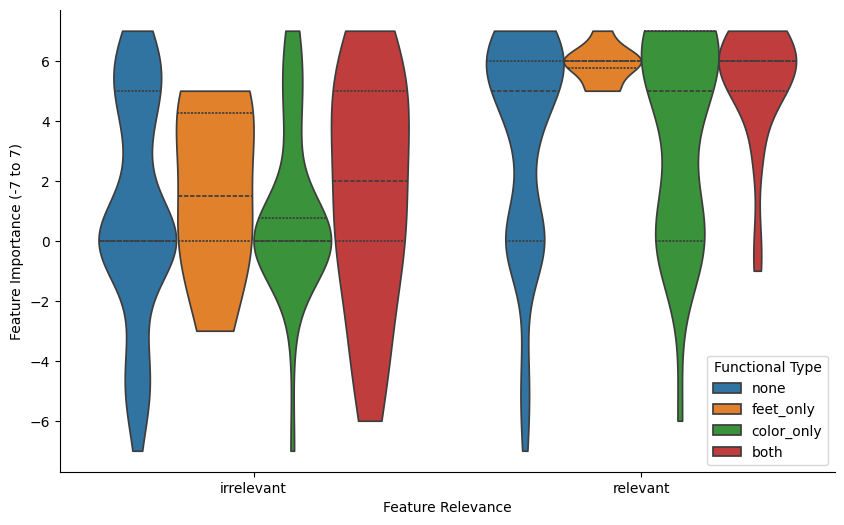

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_relevance'] = pd.Categorical(
    df_long_acc['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

df_long_acc['functional_type'] = pd.Categorical(
    df_long_acc['functional_type'],
    categories=['none', 'feet_only', 'color_only', 'both'],
    ordered=False
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long_acc,
    x='feature_relevance',
    y='feature_importance',
    hue='functional_type',
    inner='quartile',
    cut=0,
    scale='width'
)

sns.despine()
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Functional Type', loc='lower right')
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/2846583183.py:27: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


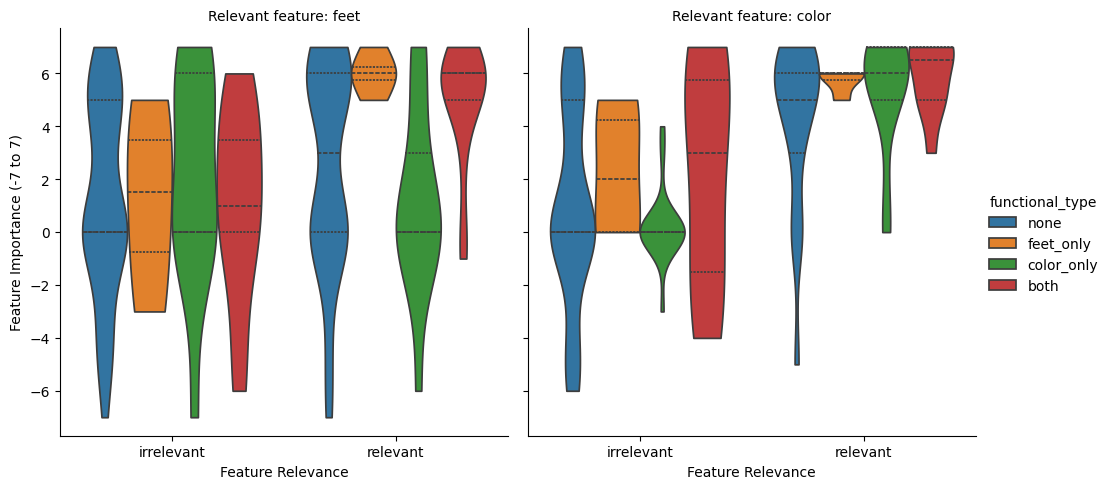

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_relevance'] = pd.Categorical(
    df_long_acc['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

df_long_acc['functional_type'] = pd.Categorical(
    df_long_acc['functional_type'],
    categories=['none', 'feet_only', 'color_only', 'both'],
    ordered=False
)

df_long_acc['relevant_dim'] = pd.Categorical(
    df_long_acc['relevant_dim'],
    categories=['feet', 'color'],
    ordered=False
)

g = sns.catplot(
    data=df_long_acc,
    x='feature_relevance',
    y='feature_importance',
    hue='functional_type',
    col='relevant_dim',
    kind='violin',
    inner='quartile',
    cut=0,
    scale='width',
    height=5,
    aspect=1
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.set_titles('Relevant feature: {col_name}')

for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

In [43]:
means = (
    df_long
    .groupby(["task", "feature_relevance"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


                     task feature_relevance      mean       std  count
0             accommodate        irrelevant  1.073333  3.643688    150
1             accommodate          relevant  3.353333  3.625296    150
2  accommodate_functional        irrelevant  1.194030  3.290200     67
3  accommodate_functional          relevant  4.567164  2.818897     67
4                 predict        irrelevant  1.087558  2.900620    217
5                 predict          relevant  2.935484  3.432616    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/1213789995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["feature_importance"]


In [47]:
import statsmodels.formula.api as smf
df_long['task'] = pd.Categorical(
    df_long['task'],
    categories=['accommodate', 'accommodate_functional', 'predict']
)

df_long['feature_relevance'] = pd.Categorical(
    df_long['feature_relevance'],
    categories=['irrelevant', 'relevant']
)
# Predicting feature importance from task and feature relevance, with random intercepts for participants
md = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"],  # random intercept per participant
    re_formula="~feature_relevance" # random slopes
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_featureimportance.csv"))

                                 Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              feature_importance
No. Observations:              868                  Method:                          REML              
No. Groups:                    217                  Scale:                           9.0821            
Min. group size:               4                    Log-Likelihood:                  -2265.0976        
Max. group size:               4                    Converged:                       Yes               
Mean group size:               4.0                                                                     
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/341896458.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


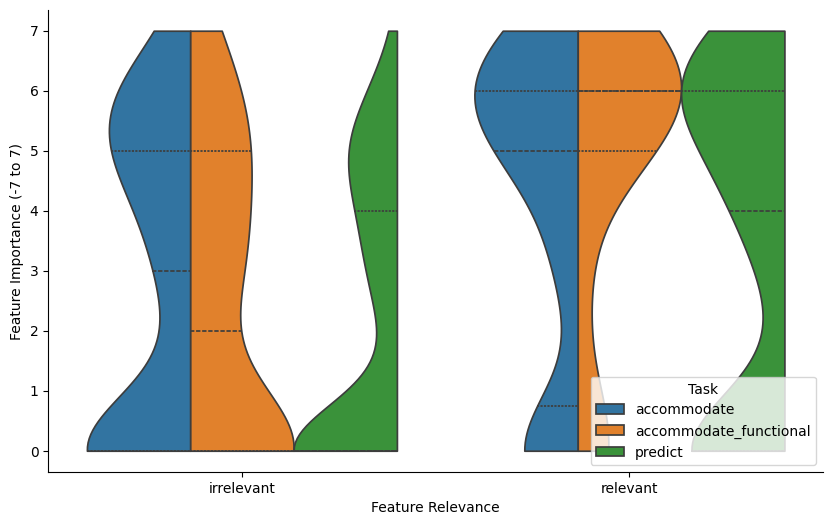

In [46]:
df_longAbs = df_long.copy()
df_longAbs["abs_feature_importance"] = df_longAbs["feature_importance"].abs()


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_longAbs['feature_relevance'] = pd.Categorical(df_longAbs['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_longAbs,
    x='feature_relevance',      # relevant / irrelevant
    y='abs_feature_importance',  # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',  
    scale = 'width',          # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.show()


In [49]:
means = (
    df_longAbs
    .groupby(["task", "feature_relevance"])["abs_feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


                     task feature_relevance      mean       std  count
0             accommodate        irrelevant  2.753333  2.608547    150
1             accommodate          relevant  4.166667  2.643002    150
2  accommodate_functional        irrelevant  2.417910  2.517510     67
3  accommodate_functional          relevant  4.776119  2.442185     67
4                 predict        irrelevant  2.046083  2.322932    217
5                 predict          relevant  3.525346  2.820322    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/4006119165.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["abs_feature_importance"]


LABELS

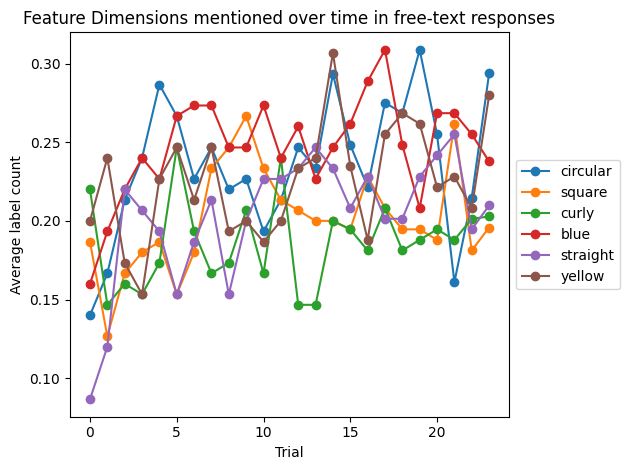

In [33]:
def count_labels_over_time(free_text_list, word_labels):
    """
    free_text_list: list of free-text responses (strings) in order
    word_labels: dict mapping label -> list of words
    Returns a list of dicts (one per trial) with counts per label
    """
    counts_over_time = []

    for text in free_text_list:
        text_lower = text.lower()  # lowercase 
        counts = {label: 0 for label in word_labels}

        for label, words in word_labels.items():
            for word in words:
                counts[label] += text_lower.count(word)  # count occurrences
        counts_over_time.append(counts)

    return counts_over_time


word_labels = {
    'circular': ['circle', 'circular', 'oval', 'round'],
    'square': ['square', 'squared', 'rectangle', 'rectangular'],
    'curly': ['curly'],
    'straight': ['straight'],
    'blue': ['blue'],
    'yellow': ['yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    
    counts = count_labels_over_time(free_text_list, word_labels)
    
    # Add participant ID and timepoint
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

# Convert to DataFrame for analysis
df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['circular','square','curly', 'blue', 'straight', 'yellow']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()


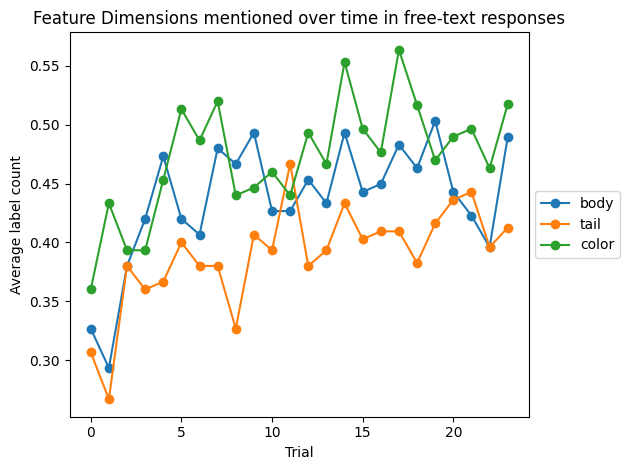

In [35]:
word_labels = {
    'body': ['circle', 'circular', 'oval', 'round', 'square', 'squared', 'rectangle', 'rectangular'],
    'tail': ['curly', 'straight'],
    'color': ['blue', 'yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    
    counts = count_labels_over_time(free_text_list, word_labels)
    
    # Add participant ID and timepoint
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

# Convert to DataFrame for analysis
df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['body', 'tail', 'color']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()

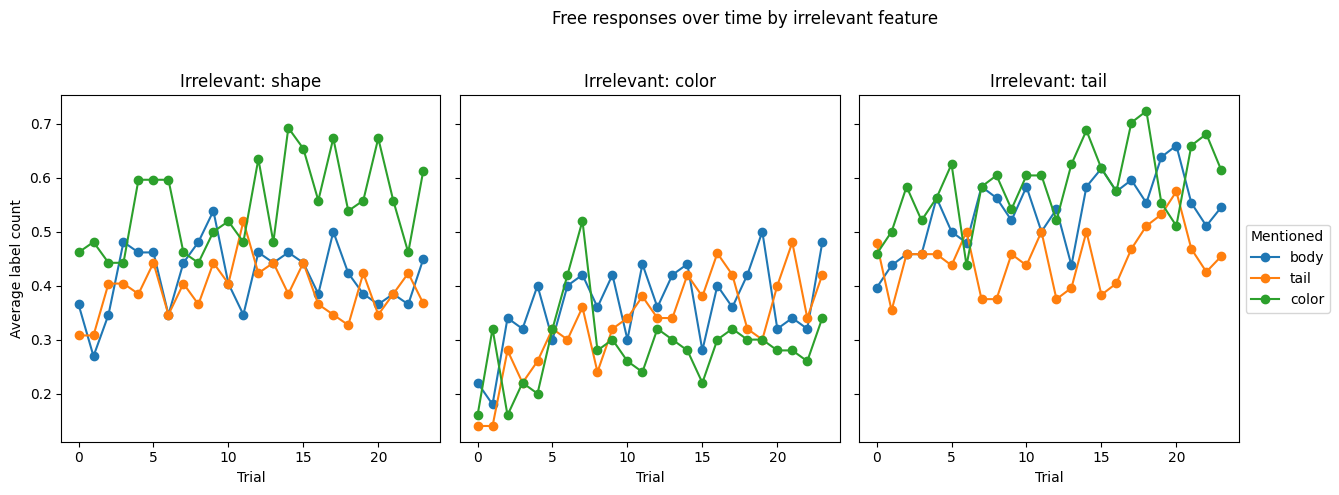

In [ ]:
def analyze_free_text_labels(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    task_name: just for plot titles
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Add participant ID, trial, and irrelevant_dim
        for trial, count_dict in enumerate(counts):
            count_dict.update({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature
            })
            all_counts.append(count_dict)

    # Convert to DataFrame
    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature
    labels = list(word_labels.keys())
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')[labels].mean()
        df_grouped.plot(ax=ax, marker='o', legend=False)
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average label count')

    plt.suptitle('Free responses over time by irrelevant feature')
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Mentioned')
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave space for suptitle
    plt.show()

    return df_counts
df_counts = analyze_free_text_labels(df_accommodate, word_labels)


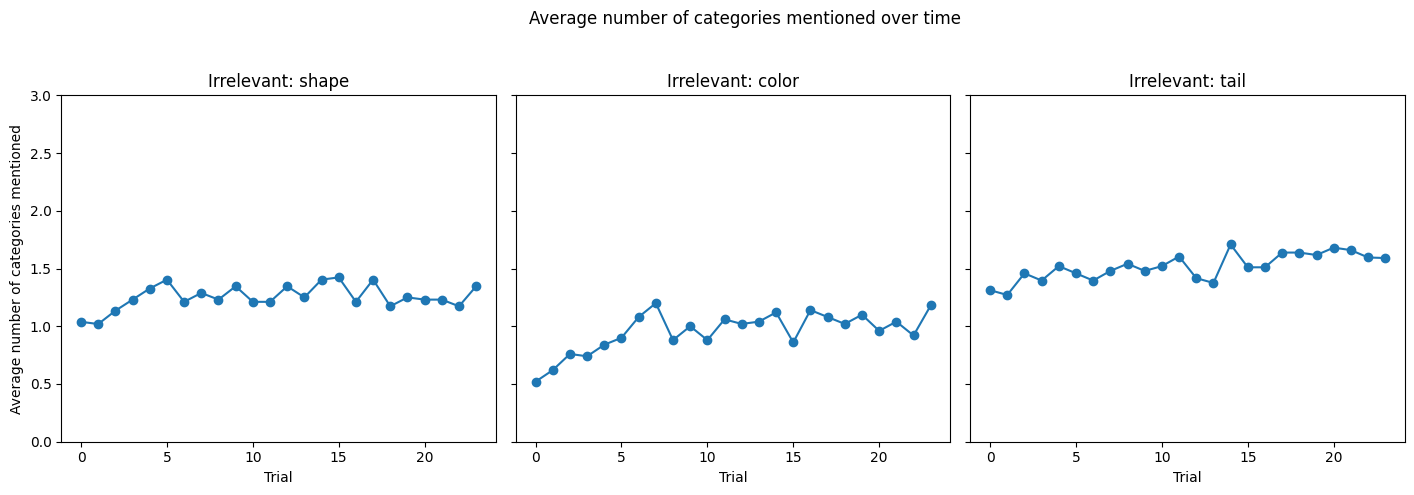

In [36]:
def analyze_free_text_num_mentions(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    Returns: df_counts with number of categories mentioned per trial and plots 0-3 mentions over time
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Convert counts into number of categories mentioned (0-3)
        for trial, count_dict in enumerate(counts):
            num_mentions = sum([1 for lbl in word_labels if count_dict[lbl] > 0])
            all_counts.append({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature,
                'num_mentions': num_mentions
            })

    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature (0-3 mentions)
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')['num_mentions'].mean()
        df_grouped.plot(ax=ax, marker='o', linestyle='-')
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average number of categories mentioned')
        ax.set_ylim(0, 3)  # 0-3 mentions possible

    plt.suptitle('Average number of categories mentioned over time')
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()

    return df_counts
df_counts = analyze_free_text_num_mentions(df_accommodate, word_labels)

In [ ]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'food_amount', 'conditionOrder', 'color_high', 'tail_high', 'shape_high', 'irrelevant_dim', 
                  'tail_importance', 'color_importance', 'shape_importance']]
df_long3 = (
    df
    .explode(['training_image_order', 'food_amount'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food_extended = (
    df_long3
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    .agg(
        food_amount=('food_amount', 'mean'),
        color_high=('color_high', 'first'),
        tail_high=('tail_high', 'first'),
        shape_high=('shape_high', 'first'),
        irrelevant_dim=('irrelevant_dim', 'first')
    )
)

avg_food_train_extended = avg_food_extended.copy()

df = avg_food_train_extended.copy()

#print(df)
df['high_or_low'] = df.apply(
    lambda row: 'high' if row[f"{row['irrelevant_dim']}_high"] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)
def get_irrelevant_value(row):
    tail, color, shape = row['item'].split('_')
    if row['irrelevant_dim'] == 'tail':
        return tail
    elif row['irrelevant_dim'] == 'color':
        return color
    elif row['irrelevant_dim'] == 'shape':
        return shape
    else:
        return None

df['irrelevant_value'] = df.apply(get_irrelevant_value, axis=1)

# Quick check
#print(df[['item', 'irrelevant_dim', 'irrelevant_value', 'tail_high', 'color_high', 'shape_high']].head(20))
df['high_or_low'] = df.apply(
    lambda row: 'high' if row['irrelevant_value'] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)

# Debug
#print(df[['item', 'irrelevant_dim', 'irrelevant_value', 'high_or_low']].head(20))
# Compute high vs low difference
high_low_diff = (
    df.groupby(['task', 'conditionOrder', 'irrelevant_dim', 'high_or_low'])['food_amount']
      .mean()             # average food amount per high/low
      .unstack(fill_value=0)  # columns become 'high' and 'low'; missing = 0
)

# Compute high_minus_low
high_low_diff['high_minus_low'] = high_low_diff['high'] - high_low_diff['low']

# Reset index for a clean table
high_low_diff = high_low_diff.reset_index()

print(high_low_diff[['task', 'conditionOrder', 'irrelevant_dim', 'high_minus_low']])



In [ ]:
import pandas as pd

# Get Relevant Columns
df = df_combined[['task', 'training_image_order', 'food_amount', 'conditionOrder',
                  'color_high', 'tail_high', 'shape_high', 'irrelevant_dim',
                  'tail_importance', 'color_importance', 'shape_importance']]

# Explode lists into rows
df_long = df.explode(['training_image_order', 'food_amount']).rename(columns={'training_image_order': 'item'})

# 3️Compute mean food amount per item
df_items = (
    df_long.groupby(['task', 'conditionOrder', 'item'], as_index=False)
           .agg(
               food_amount=('food_amount', 'mean'),
               color_high=('color_high', 'first'),
               tail_high=('tail_high', 'first'),
               shape_high=('shape_high', 'first'),
               irrelevant_dim=('irrelevant_dim', 'first'),
               tail_importance=('tail_importance', 'first'),
               color_importance=('color_importance', 'first'),
               shape_importance=('shape_importance', 'first')
           )
)

# Extract actual value of the irrelevant dimension from the item
def get_irrelevant_value(row):
    tail, color, shape = row['item'].split('_')
    if row['irrelevant_dim'] == 'tail':
        return tail
    elif row['irrelevant_dim'] == 'color':
        return color
    elif row['irrelevant_dim'] == 'shape':
        return shape

df_items['irrelevant_value'] = df_items.apply(get_irrelevant_value, axis=1)

# Determine if each item is high or low along the irrelevant dimension
df_items['high_or_low'] = df_items.apply(
    lambda row: 'high' if row['irrelevant_value'] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)

# Get importance for irrelevant feature for each item
df_items['irrelevant_importance'] = df_items.apply(
    lambda row: row[f"{row['irrelevant_dim']}_importance"], axis=1
)

# Compute high vs low differences and keep importance score
agg = (
    df_items.groupby(['task', 'conditionOrder', 'irrelevant_dim', 'high_or_low'])
            .agg(
                food_amount_mean=('food_amount', 'mean'),
                irrelevant_importance_mean=('irrelevant_importance', 'mean')
            )
            .unstack(fill_value=0)  # separate 'high' and 'low'
)

# Compute high_minus_low
agg['high_minus_low'] = agg['food_amount_mean']['high'] - agg['food_amount_mean']['low']

# Get irrelevant importance
agg['irrelevant_importance'] = agg['irrelevant_importance_mean']['high']

# Reset index and select final columns
final_df = agg.reset_index()[['task', 'conditionOrder', 'irrelevant_dim', 'high_minus_low', 'irrelevant_importance']]
final_df['high_minus_low'] = pd.to_numeric(final_df['high_minus_low'], errors='coerce')
final_df['irrelevant_importance'] = pd.to_numeric(final_df['irrelevant_importance'], errors='coerce')

print(final_df.head(10))


In [ ]:
# Position-based decoding
FEATURE_INDEX = {
    "tail":  0,  # T or N
    "color": 1,  # B or Y
    "shape": 2   # S or C
}
def extract_feature(stimulus, feature):
    """
    stimulus: string like 'T_B_S'
    feature: 'tail', 'color', or 'shape'
    """
    return stimulus.split("_")[FEATURE_INDEX[feature]]
mapping = {
    "tail":  {"T": 1, "N": 0},
    "shape": {"S": 1, "C": 0},
    "color": {"B": 1, "Y": 0}
}
cols_to_keep = [
    "participant",
    "task",
    "conditionOrder",
    "irrelevant_dim",
    "food_amount",
    "training_color",
    "training_shape",
    "training_tail",
    "training_image_order",
    "tail_importance",
    "shape_importance",
    "color_importance"
]

def compute_true_irrelevant_assoc(row):
    irrel_feat = row["irrelevant_dim"]

    # Food values
    food = np.array(
        ast.literal_eval(row["food_amount"])
        if isinstance(row["food_amount"], str)
        else row["food_amount"],
        dtype=float
    )

    # Extract irrelevant feature value per training trial
    irrel_vals = np.array([
        mapping[irrel_feat][
            extract_feature(stim, irrel_feat)
        ]
        for stim in row["training_image_order"]
    ])

    mean_high = food[irrel_vals == 1].mean()
    mean_low  = food[irrel_vals == 0].mean()

    return mean_high - mean_low
df_irrel_truth = df_combined[cols_to_keep].copy()

df_irrel_truth["true_irrelevant_assoc"] = df_irrel_truth.apply(
    compute_true_irrelevant_assoc,
    axis=1
)

df_irrel_truth[
    ["task", "conditionOrder", "irrelevant_dim", "true_irrelevant_assoc", "color_importance", "shape_importance", "tail_importance"]
]

In [ ]:
def get_irrelevant_importance(row):
    return row[f"{row['irrelevant_dim']}_importance"]

df_plot = df_irrel_truth.copy()
df_plot["irrelevant_importance"] = df_plot.apply(
    get_irrelevant_importance, axis=1
)

plt.figure(figsize=(9, 4))

sns.scatterplot(
    data=df_plot,
    x="true_irrelevant_assoc",
    y="irrelevant_importance",
    hue="task",
    style="task",
    s=60
)

for task, sub in df_plot.groupby("task"):
    sns.regplot(
        data=sub,
        x="true_irrelevant_assoc",
        y="irrelevant_importance",
        scatter=False,
        ci=None,
        label=f"{task} fit"
    )

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel("True irrelevant association")
plt.ylabel("Irrelevant dimension rating")
plt.title("Irrelevant Dimension Rating vs True Association")
plt.legend(
    title="Task",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


